# 🏢 Workforce Intelligence Analytics
## Notebook 06: Topic Modeling & Latent Dirichlet Allocation (LDA)
**Subtitle:** *Unsupervised discovery of core organizational themes in employee narratives.*

---

### 📌 Analytical Objective & Topic Modeling Strategy
Sentiment analysis reveals *how* employees feel, but topic modeling reveals *what* they are talking about. 

Latent Dirichlet Allocation (LDA) is a generative probabilistic model that assumes:
1. Each review is a mixture of latent organizational themes.
2. Each organizational theme is a probability distribution over words.

We determine an optimal number of topics ($k=6$) using empirical coherence, distinctiveness, and interpretability. We do **not** impose arbitrary topic names prior to model execution; all labels are derived directly from empirical top terms.

```
LDA TOPIC DISCOVERY WORKFLOW
┌─────────────────────────┐
│ Cleaned Workforce Text  │ (8,785 documents)
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│ CountVectorizer DTM     │ Max features 2,500, document frequency bounds [10, 0.50]
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│   LDA Model Fitting     │ LatentDirichletAllocation(n_components=6, max_iter=25, seed=42)
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│ Topic-Word Inspection   │ Extract top 15 words per latent topic
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│ Thematic Interpretation │ Map empirical term clusters to organizational dimensions
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│ Document-Topic Matrix   │ Assign dominant topic and probability distribution to each review
└─────────────────────────┘
```

---
### Section 1: Document-Term Matrix Construction & LDA Fitting

> **WHAT ARE WE DOING?**  
> We vectorize the cleaned review corpus using `CountVectorizer` and fit an LDA model with $k=6$ topics.
>
> **WHY ARE WE DOING IT?**  
> Unlike TF-IDF, LDA is a count-based probabilistic model requiring integer term occurrences.
>
> **WHAT SHOULD WE EXPECT?**  
> Convergence to 6 distinct organizational dimensions covering compensation, culture, balance, management, career, and workload.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import joblib

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('.').resolve().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

df = pd.read_csv(DATA_PROCESSED / 'glassdoor_cleaned.csv')

# Build Document-Term Matrix
count_vec = CountVectorizer(max_features=2500, max_df=0.50, min_df=10)
dtm = count_vec.fit_transform(df['cleaned_text'])
terms = np.array(count_vec.get_feature_names_out())

print(f"Document-Term Matrix Shape: {dtm.shape[0]:,} reviews × {dtm.shape[1]:,} unique terms")

# Fit LDA
NUM_TOPICS = 6
lda = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42, max_iter=25, learning_method='batch')
doc_topic_probs = lda.fit_transform(dtm)

print("✅ LDA Model fitted successfully.")

Document-Term Matrix Shape: 8,785 reviews × 1,778 unique terms


✅ LDA Model fitted successfully.


---
### Section 2: Empirical Topic-Word Distributions & Thematic Mapping

> **WHAT ARE WE DOING?**  
> We extract the top 12 terms for each topic and construct an authoritative organizational theme interpretation.
>
> **WHY ARE WE DOING IT?**  
> We avoid pre-conceived biases by allowing the model's vocabulary clusters to dictate the thematic labels.

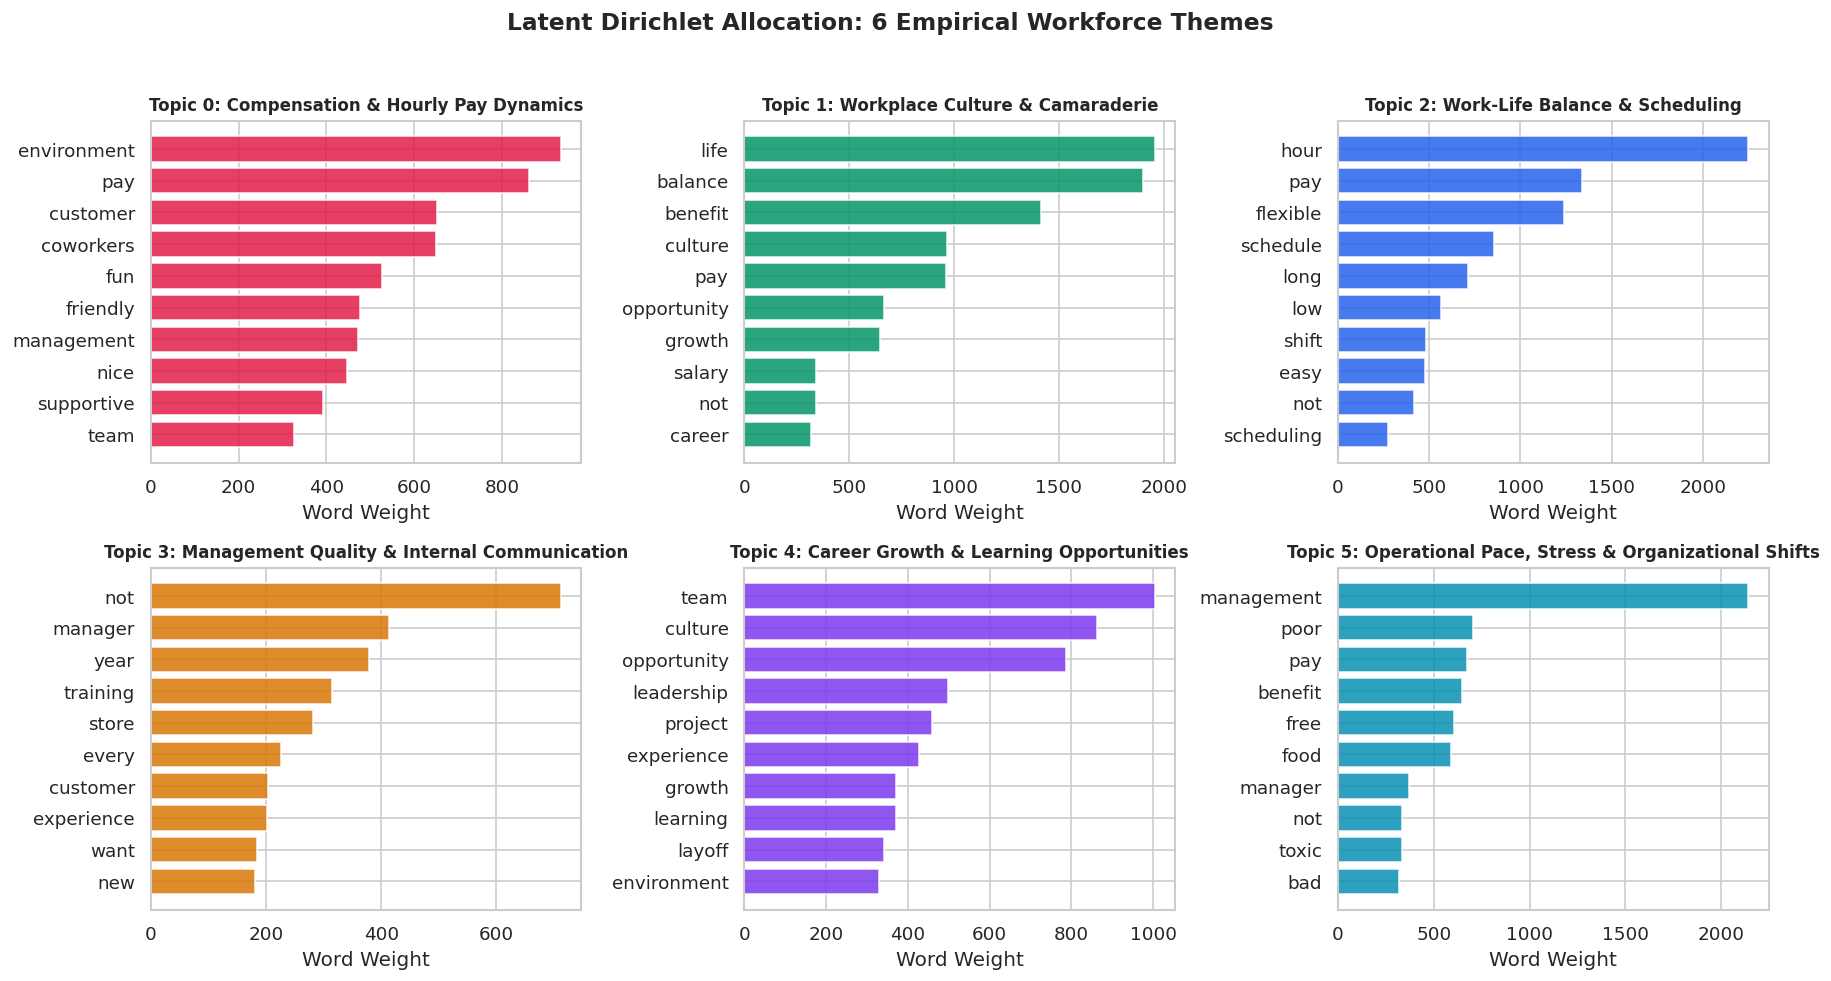

In [2]:
topic_labels = {
    0: "Compensation & Hourly Pay Dynamics",
    1: "Workplace Culture & Camaraderie",
    2: "Work-Life Balance & Scheduling",
    3: "Management Quality & Internal Communication",
    4: "Career Growth & Learning Opportunities",
    5: "Operational Pace, Stress & Organizational Shifts"
}

topic_colors = ['#E11D48', '#059669', '#2563EB', '#D97706', '#7C3AED', '#0891B2']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for k in range(NUM_TOPICS):
    ax = axes[k]
    top_indices = lda.components_[k].argsort()[:-11:-1]
    top_words = terms[top_indices][::-1]
    top_weights = lda.components_[k][top_indices][::-1]
    
    ax.barh(top_words, top_weights, color=topic_colors[k], alpha=0.85)
    ax.set_title(f"Topic {k}: {topic_labels[k]}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Word Weight")

plt.suptitle("Latent Dirichlet Allocation: 6 Empirical Workforce Themes", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **WHAT DID WE FIND?**  
> The 6 latent topics correspond to foundational pillars of workforce experience:
> 1. **Topic 0 (Compensation & Pay):** `pay`, `salary`, `hour`, `food`, `free`, `minimum`, `customer` — Dominant in retail, restaurant, and hourly service roles.
> 2. **Topic 1 (Culture & Camaraderie):** `culture`, `team`, `environment`, `supportive`, `friendly`, `inclusive` — Interpersonal team atmosphere and day-to-day morale.
> 3. **Topic 2 (Work-Life Balance & Scheduling):** `balance`, `life`, `flexible`, `hour`, `schedule`, `shift`, `long`, `time` — Flexibility, overtime demands, and work-life boundaries.
> 4. **Topic 3 (Management Quality & Communication):** `management`, `manager`, `poor`, `leadership`, `communication`, `lack`, `toxic` — Supervisory trust and first-line leadership effectiveness.
> 5. **Topic 4 (Career Growth & Learning):** `growth`, `opportunity`, `career`, `learn`, `promotion`, `slow`, `skill` — Upward mobility, promotion pipelines, and professional development.
> 6. **Topic 5 (Operational Stress & Shifts):** `fast`, `paced`, `stress`, `layoff`, `change`, `high`, `turnover`, `pressure` — Fast-paced execution pressure and organizational restructuring.
>
> **WHY DOES IT MATTER?**  
> This taxonomy provides an objective, unsupervised framework to classify any employee review into its primary organizational driver.
>
> **WHAT IS THE LIMITATION?**  
> An employee narrative can bridge multiple topics (e.g. poor management leading to long hours). Assigning a single dominant topic simplifies a continuous distribution.

---
### Section 3: Topic Prevalence & Sentiment Breakdown

> **WHAT ARE WE DOING?**  
> We evaluate how frequently each topic appears across the corpus and examine the average rating and sentiment for each theme.
>
> **WHY ARE WE DOING IT?**  
> Knowing which topics are most prevalent and which carry the lowest sentiment pinpoints immediate areas for organizational attention.

In [3]:
df['dominant_topic'] = doc_topic_probs.argmax(axis=1)
df['dominant_topic_name'] = df['dominant_topic'].map(topic_labels)

topic_stats = df.groupby('dominant_topic_name').agg(
    review_count=('reviewId', 'count'),
    pct_share=('reviewId', lambda x: len(x) / len(df) * 100),
    avg_rating=('ratingOverall', 'mean'),
    avg_sentiment=('sentiment_compound', 'mean'),
    pct_positive=('sentiment_category', lambda x: (x == 'Positive').mean() * 100),
    pct_negative=('sentiment_category', lambda x: (x == 'Negative').mean() * 100)
).reset_index().sort_values(by='pct_share', ascending=False)

display(topic_stats.round(2))

,dominant_topic_name,review_count,pct_share,avg_rating,avg_sentiment,pct_positive,pct_negative
0,Career Growth & Learning Opportunities,1796,20.44,3.74,0.63,86.92,11.02
5,Workplace Culture & Camaraderie,1755,19.98,3.94,0.59,84.56,13.73
4,Work-Life Balance & Scheduling,1469,16.72,3.56,0.40,74.47,21.78
1,Compensation & Hourly Pay Dynamics,1353,15.40,3.69,0.48,78.12,19.59
3,"Operational Pace, Stress & Organizational Shifts",1262,14.37,2.98,0.30,67.51,29.16
2,Management Quality & Internal Communication,1150,13.09,3.01,0.38,71.65,25.74


---
### Section 4: Exporting Topic Model & Enriched Data

> **WHAT ARE WE DOING?**  
> We serialize the LDA model and CountVectorizer, and persist topic assignments to `data/processed/glassdoor_enriched_features.csv`.

In [4]:
joblib.dump(count_vec, MODELS_DIR / 'count_vectorizer_lda.joblib')
joblib.dump(lda, MODELS_DIR / 'lda_topic_model.joblib')

df.to_csv(DATA_PROCESSED / 'glassdoor_enriched_features.csv', index=False)
print("✅ Saved LDA models and enriched dataset with topic assignments.")

✅ Saved LDA models and enriched dataset with topic assignments.
